<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 2 — Clasificación con k-NN y Naive Bayes</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Se te proporciona el dataset **Pima Indians Diabetes** (NIDDK, 1988), un clásico benchmark biomédico que contiene registros de **768 mujeres** con variables metabólicas y demográficas. La variable objetivo es `Outcome` (0 = no diabética, 1 = diabética con diabetes mellitus tipo 2).

Tu misión: construir, evaluar y comparar un clasificador **k-NN** y un **Naive Bayes Gaussiano** para predecir diabetes a partir de variables clínicas. Para cada decisión de diseño deberás **justificar clínicamente** tu elección.

---
> **Dataset:** `diabetes.csv`  
> **Fuente:** Smith, J.W. et al. (1988). *Using the ADAP Learning Algorithm to Forecast the Onset of Diabetes Mellitus*. Proceedings of the Annual Symposium on Computer Application in Medical Care.  
> Disponible en: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

---

### Variables del dataset

| Variable | Descripción | Unidad |
|---|---|---|
| Pregnancies | Número de embarazos | — |
| Glucose | Glucosa plasmática en ayunas (OGTT 2h) | mg/dL |
| BloodPressure | Presión arterial diastólica | mmHg |
| SkinThickness | Grosor del pliegue tricipital | mm |
| Insulin | Insulina sérica a las 2h | μU/mL |
| BMI | Índice de masa corporal | kg/m² |
| DiabetesPedigreeFunction | Score hereditario de diabetes | — |
| Age | Edad | años |
| **Outcome** | **Diagnóstico de diabetes** | **0/1** |

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

---
## Ejercicio 1 — Diseño previo al código (conceptual)

> **Antes de escribir una línea de código**, razona sobre el problema.

### 1.1 — ¿k-NN o Naive Bayes? ¿O ambos?

Para este dataset de variables clínicas continuas, responde **antes de ver los datos**:

1. ¿Qué suposición hace Naive Bayes sobre las features? ¿Es razonable para glucosa, IMC y presión arterial? ¿Por qué?
2. k-NN requiere escalar los datos. Si no lo hicieras, ¿qué feature dominaría la distancia euclidiana y por qué? (pista: revisa las unidades de la tabla)
3. Para un sistema de tamizaje masivo (screening) de diabetes en una posta médica, ¿priorizarías **recall** o **precision**? Argumenta clínicamente.
4. Si la prevalencia de diabetes en la población fuera solo 5% (vs ~35% en este dataset), ¿cómo afectaría eso a la interpretación del posterior de Naive Bayes?

**📝 Tu respuesta (edita esta celda):**
1. Naive Bayes asume que las features son independientes entre sí, dada la clase. Sin embargo, esta forma de simplificación no es razonable, porque en la vida real, muchas variables clínicas están relacionadas. Por ejemplo, en el caso de las tres variables mencionadas, estas sí están relacionadas metabólicamente: un IMC alto indica obesidad y esta condición favorece la resistencia a la insulina, generando niveles altos de glucosa en la sangre, y estas dos condiciones aumentan gravemente la presión arterial. Aún así, siendo una simplificación, el modelo puede funcionar correctamente.
2. La feature que dominaría sería la Insulina, porque si observamos las unidades y los valores del .csv, la mayoria de variables poseen rangos números pequeños, es decir, la diferencia entre el valor máximo y mínimo es poca. En cambio, en el caso de la Insulina, su rango es enorme, ya que sus valores van desde el 0 hasta unidades mayores a 800. Entonces, si una diferencia tan grande se eleva al cuadrado, la Insulina genera diferencias más grandes.
3. Se debería priorizar recall, ya que en el caso de un tamizaje real, el objetivo principal es detectar la mayor cantidad de casos sospechosos. Es mejor obtener un falso positivo que sería realizar una evaluación adicional a una paciente sana para descarte, que obtener un falso negativo que significaría dejar pasar a una paciente con diabetes no detectada, lo que generaría que no se le haga seguimiento, no se pueda intervenir y provocaría que la diabetes empeore.
4. Si la prevalencia real es menor, el prior de diabetes de Naive Bayes bajaría. Entonces, como consecuencia el modelo se haría más 'conservador', ya que bajaría la probabilidad posterior para la clase positiva y se necesitaría evidencia más fuerte para una clasificación positiva, generando que se tienda a predecir menos casos positivos.

### 1.2 — Pipeline completo

Dibuja (en texto o diagrama) el pipeline que vas a implementar, indicando **en qué paso** se hace el train/test split y por qué es importante no cruzar esa frontera.

```
diabetes.csv
    │
    ▼
[ Paso A ] Carga e inspección inicial de datos  ← ¿Qué haces aquí?
    │
    ▼
[ Paso B ] Sí.  ← ¿Aquí ya haces el split? ¿Por qué?
    │      Porque el split se debe realizar antes de la imputación y escalamiento de valores. Si se rellenan los vacíos 
    │      con la mediana del 100% de los datos, el modelo no evaluará datos totalmente desconocidos en el train data, 
    │      provocando que poseea una precisión alta de forma artificial. De la misma forma, si se escala antes del escalamiento, 
    │      el modelo sabrá data que solo debería pertenecer al train data. Es decir, se produce data leakage.
    │
    ├──────── TRAIN ──────────────────────────────────────────────┐
    │                                                             │
    ▼                                                             │
[ Paso C ] Solamente se estima la imputación y el escalado. ← ¿Qué estimas SOLO con train?        
    │                                                             │
    ▼                                                             │
[ Paso D ] Ajuste de los clasificadores (k-NN o GaussianNB) ← Entrenamiento de modelos           
    │                                                             │
    └──────── TEST ── (aplicas lo estimado en C) ─────────────────┘
    │
    ▼
[ Paso E ] Evaluación usando parámetros (accuracy, precision, recall y F1)  ← Evaluación final
```

**📝 Tu respuesta (edita esta celda):** completa los `___` del diagrama.

---
## Ejercicio 2 — Setup y carga de datos

In [ ]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

In [4]:
# Colores UPCH
UPCH_RED  = '#8B0000'
UPCH_BLUE = '#1565C0'
UPCH_GRAY = '#4A4A4A'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

# Ruta del dataset
DATA_PATH = Path('Dataset')

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


### Paso 2.1 — Carga y primera inspección

In [5]:
df = pd.read_csv(DATA_PATH / 'diabetes.csv')

print(f'Shape: {df.shape}')
print(f'\nPrimeras filas:')
df.head()

Shape: (768, 9)

Primeras filas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# Tipos de datos y valores nulos
print('Tipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nEstadísticas descriptivas:')
df.describe()

Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Estadísticas descriptivas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Paso 2.2 — Distribución de clases y desbalance

Distribución de clases:
  No diabética (0): 500 pacientes (65.1%)
  Diabética    (1): 268 pacientes (34.9%)


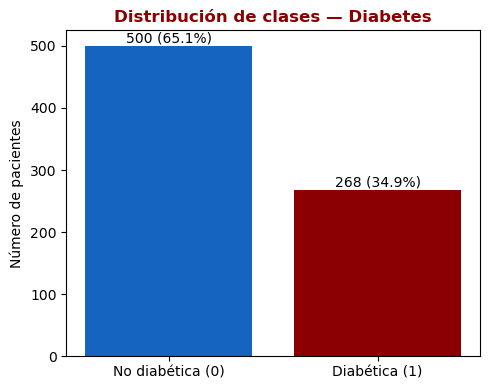

→ ¿Hay desbalance? ¿Qué clasificador trivial daría accuracy alta sin detectar nada útil?
Sí hay presencia de un desbalance moderado (65.1% vs 34.9%). Un clasificador trivial que predice siempre la clase mayoritaria 
alcanzaría un accuracy alto, pero sería inútil clínicamente, ya que no detectaría ningún caso de diabetes.


In [10]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: calcula el conteo y porcentaje de cada clase en 'Outcome'
conteo=df['Outcome'].value_counts().sort_index()
pct=df['Outcome'].value_counts(normalize=True).sort_index()*100

print('Distribución de clases:')
print(f'  No diabética (0): {conteo[0]} pacientes ({pct[0]:.1f}%)')
print(f'  Diabética    (1): {conteo[1]} pacientes ({pct[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))

# TODO 2: grafica las barras con colores [UPCH_BLUE, UPCH_RED]
bars=ax.bar(conteo.index, conteo.values, color=[UPCH_BLUE, UPCH_RED])

ax.set_title('Distribución de clases — Diabetes', fontweight='bold', color=UPCH_RED)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No diabética (0)', 'Diabética (1)'])
ax.set_ylabel('Número de pacientes')

# TODO 3: agrega el valor numérico y porcentaje encima de cada barra
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{conteo[i]} ({pct[i]:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.savefig('distribucion_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Hay desbalance? ¿Qué clasificador trivial daría accuracy alta sin detectar nada útil?')
print('Sí hay presencia de un desbalance moderado (65.1% vs 34.9%). Un clasificador trivial que predice siempre la clase mayoritaria \n'
'alcanzaría un accuracy alto, pero sería inútil clínicamente, ya que no detectaría ningún caso de diabetes.')

---
## Ejercicio 3 — Limpieza: valores fisiológicamente imposibles

Este dataset tiene un problema clásico: variables como Glucosa, BloodPressure, BMI e Insulin tienen valores **0** que son fisiológicamente imposibles. Son errores de adquisición codificados como 0 en lugar de `NaN`.

In [11]:
# Columnas que NO pueden ser 0 fisiológicamente
cols_no_cero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Valores = 0 por columna (antes de limpiar):')
for col in cols_no_cero:
    n_cero = (df[col] == 0).sum()
    print(f'  {col:<25} {n_cero:>4} ({100*n_cero/len(df):.1f}%)')

Valores = 0 por columna (antes de limpiar):
  Glucose                      5 (0.7%)
  BloodPressure               35 (4.6%)
  SkinThickness              227 (29.6%)
  Insulin                    374 (48.7%)
  BMI                         11 (1.4%)


In [13]:
df_clean = df.copy()

# --- COMPLETA EL CÓDIGO ---
# TODO: reemplaza los valores 0 por NaN en todas las columnas de cols_no_cero
# Pista: usa un loop o df_clean[cols_no_cero].replace()
df_clean[cols_no_cero]=df_clean[cols_no_cero].replace(0, np.nan)

print('Valores NaN tras limpieza:')
print(df_clean[cols_no_cero].isnull().sum())
print('\n→ La imputación se realizará DESPUÉS del split, solo con estadísticas de train.')

Valores NaN tras limpieza:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

→ La imputación se realizará DESPUÉS del split, solo con estadísticas de train.


---
## Ejercicio 4 — EDA: ¿qué features separan mejor las clases?

Antes de entrenar cualquier modelo, exploramos visualmente qué variables tienen más **poder discriminativo**.

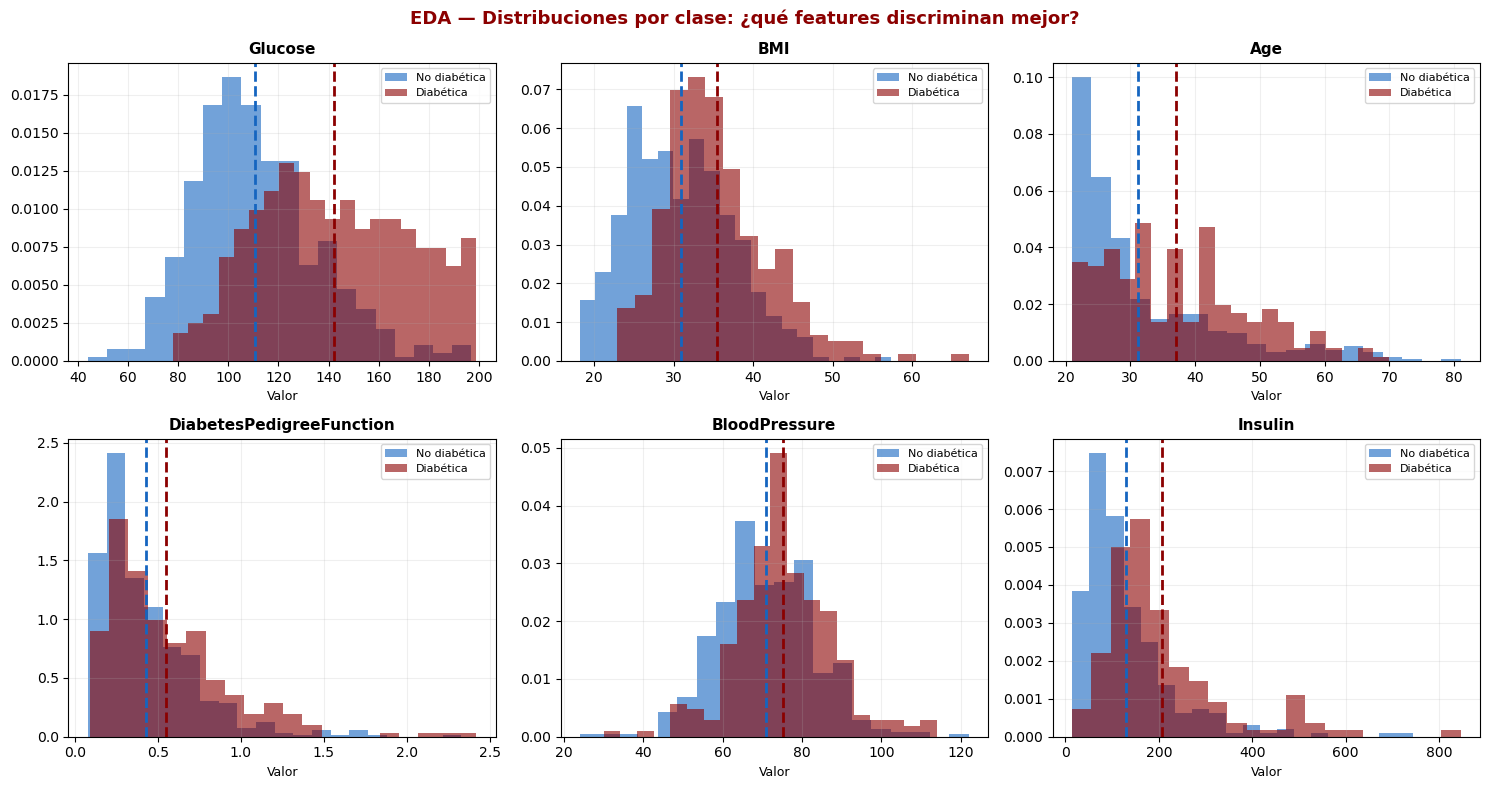

→ ¿Qué feature tiene las distribuciones más separadas? ¿Cuál tiene más solapamiento?
La característica con mayor separación es Glucose, ya que presenta diferencias claras entre las distribuciones 
de ambas clases. Por otro lado, BloodPressure presenta el mayor solapamiento, indicando baja discapacidad discriminativa


In [15]:
features_num = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'BloodPressure', 'Insulin']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    ax = axes[i]

    # --- COMPLETA EL CÓDIGO ---
    # TODO: grafica histogramas superpuestos (density=True) para clase 0 y clase 1
    # Usa alpha=0.6, UPCH_BLUE para clase 0, UPCH_RED para clase 1
    # Agrega una línea vertical con la media de cada clase
    for clase, color, label in [(0, UPCH_BLUE, 'No diabética'), (1, UPCH_RED, 'Diabética')]:
        valores = df_clean[df_clean['Outcome'] == clase][feat].dropna()
        # TODO: hist y línea de media
        ax.hist(valores, bins=20, density=True, alpha=0.6, color=color, label=label)
        media = valores.mean()
        ax.axvline(media, color=color, linestyle='--', linewidth=2)

    ax.set_title(feat, fontweight='bold', fontsize=11)
    ax.set_xlabel('Valor', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle('EDA — Distribuciones por clase: ¿qué features discriminan mejor?',
             fontsize=13, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué feature tiene las distribuciones más separadas? ¿Cuál tiene más solapamiento?')
print('La característica con mayor separación es Glucose, ya que presenta diferencias claras entre las distribuciones \n'
      'de ambas clases. Por otro lado, BloodPressure presenta el mayor solapamiento, indicando baja discapacidad discriminativa')

### Paso 4.2 — Mapa de correlación

Naive Bayes asume independencia condicional. ¿Hay correlaciones fuertes entre features?

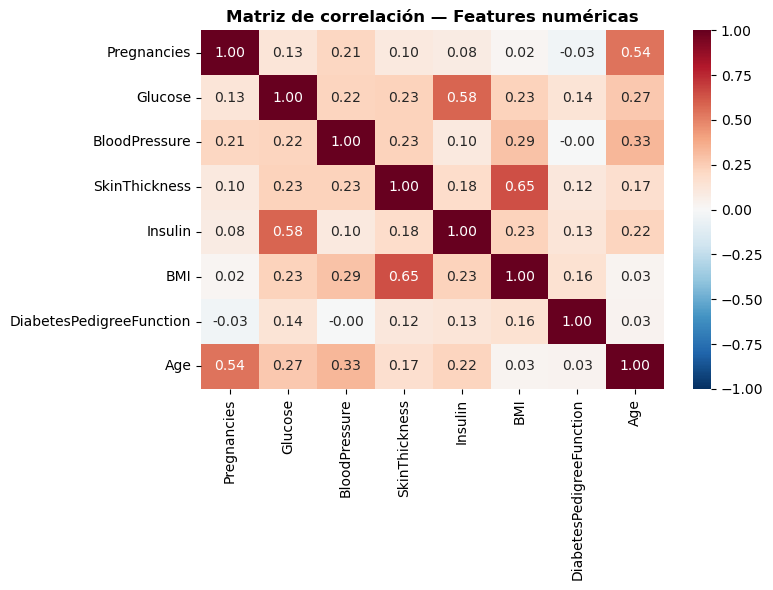

→ Identifica los pares de features con |correlación| > 0.5.
  ¿Viola esto la suposición de Naive Bayes? ¿Cuánto impacto tendrá?
Sí, existen pares de variables con correlación |r| > 0.5, lo que viola la suposición de 
de independencia condicional de Naive Bayes. Sin embargo, en la práctica el impacto es moderado, 
ya que el modelo es relativamente robusto.


In [17]:
# --- COMPLETA EL CÓDIGO ---
# TODO: calcula la matriz de correlación de df_clean (solo features numéricas, sin Outcome)
#       y grafícala con seaborn heatmap. Incluye: cmap='RdBu_r', vmin=-1, vmax=1, annot=True
corr=df_clean.drop(columns=['Outcome']).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fmt='.2f')
plt.title('Matriz de correlación — Features numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

print('→ Identifica los pares de features con |correlación| > 0.5.')
print('  ¿Viola esto la suposición de Naive Bayes? ¿Cuánto impacto tendrá?')
print('Sí, existen pares de variables con correlación |r| > 0.5, lo que viola la suposición de \n'
      'de independencia condicional de Naive Bayes. Sin embargo, en la práctica el impacto es moderado, \n'
      'ya que el modelo es relativamente robusto.')

---
## Ejercicio 5 — Preprocesamiento: split, imputación y escalado

In [18]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: separa features (X) y target (y) de df_clean
X=df_clean.drop(columns=['Outcome'])
y=df_clean['Outcome']

# TODO 2: haz train_test_split con test_size=0.2, random_state=42, estratificado
X_train, X_test, y_train, y_test=train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape}  →  {(y_train==1).sum()} diabéticas ({100*(y_train==1).mean():.1f}%)')
print(f'Test:  {X_test.shape}   →  {(y_test==1).sum()} diabéticas ({100*(y_test==1).mean():.1f}%)')

Train: (614, 8)  →  214 diabéticas (34.9%)
Test:  (154, 8)   →  54 diabéticas (35.1%)


In [20]:
# --- COMPLETA EL CÓDIGO ---
# TODO: imputa los NaN con la MEDIANA de train (no de todo el dataset)
#       Aplica la mediana de train también al test

mediana_train=X_train.median()
X_train_imp=X_train.fillna(mediana_train)
X_test_imp=X_test.fillna(mediana_train)

print(f'NaN en train tras imputación: {np.isnan(X_train_imp).sum()}')
print(f'NaN en test  tras imputación: {np.isnan(X_test_imp).sum()}')

NaN en train tras imputación: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
NaN en test  tras imputación: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [21]:
# --- COMPLETA EL CÓDIGO ---
# TODO: escala con StandardScaler
#       - fit_transform sobre X_train_imp
#       - transform (sin fit) sobre X_test_imp

scaler = StandardScaler()
X_train_sc=scaler.fit_transform(X_train_imp)
X_test_sc=scaler.transform(X_test_imp)

print(f'Train escalado — media: {X_train_sc.mean():.4f}  std: {X_train_sc.std():.4f}')

Train escalado — media: 0.0000  std: 1.0000


---
## Ejercicio 6 — Entrenamiento de modelos

### Paso 6.1 — Naive Bayes Gaussiano

In [22]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena un GaussianNB con X_train_imp (NB no necesita escalado, usa datos imputados)
gnb=GaussianNB()
gnb.fit(X_train_imp, y_train)

# TODO 2: predice sobre X_test_imp
y_pred_gnb=gnb.predict(X_test_imp)

# TODO 3: imprime accuracy
acc_gnb=accuracy_score(y_test, y_pred_gnb)
print(f'Naive Bayes — Accuracy: {acc_gnb:.4f}')

Naive Bayes — Accuracy: 0.7013


### Paso 6.2 — k-NN: selección de k óptimo

Entrena k-NN para **k = 1, 3, 5, 7, 9, 11, 15** usando validación interna sobre train (80/20). Grafica train vs val accuracy y selecciona k óptimo.

In [23]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: divide X_train_sc / y_train en subconjuntos train_sub / val (80/20, estratificado)
X_tr_sub, X_val, y_tr_sub, y_val=train_test_split(
    X_train_sc, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# TODO 2: itera sobre k_values = [1, 3, 5, 7, 9, 11, 15]
#          guarda acc en train_sub y val para cada k
k_values = [1, 3, 5, 7, 9, 11, 15]
acc_tr_list  = []
acc_val_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_sub, y_tr_sub)
    
    # Accuracy en train_sub
    y_pred_tr = knn.predict(X_tr_sub)
    acc_tr = accuracy_score(y_tr_sub, y_pred_tr)
    acc_tr_list.append(acc_tr)
    
    # Accuracy en validation
    y_pred_val = knn.predict(X_val)
    acc_val = accuracy_score(y_val, y_pred_val)
    acc_val_list.append(acc_val)

# TODO 3: identifica k óptimo (argmax de acc_val_list)
k_optimo=k_values[np.argmax(acc_val_list)]
print(f'k óptimo = {k_optimo}  (val accuracy = {max(acc_val_list):.4f})')

k óptimo = 15  (val accuracy = 0.8211)


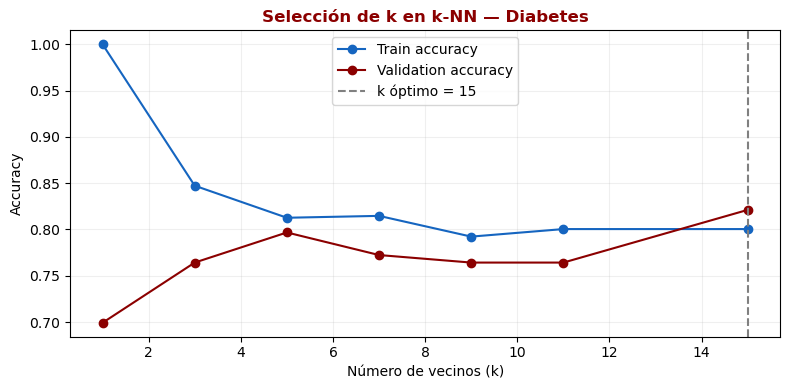

In [24]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica train vs val accuracy en función de k
# Incluye: línea vertical en k óptimo, leyenda, títulos, colores UPCH

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(k_values, acc_tr_list, marker='o', color=UPCH_BLUE, label='Train accuracy')
ax.plot(k_values, acc_val_list, marker='o', color=UPCH_RED, label='Validation accuracy')

# Línea vertical en k óptimo
ax.axvline(k_optimo, color='gray', linestyle='--', label=f'k óptimo = {k_optimo}')

ax.set_title('Selección de k en k-NN — Diabetes', fontweight='bold', color=UPCH_RED)
ax.set_xlabel('Número de vecinos (k)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('knn_seleccion_k_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# --- COMPLETA EL CÓDIGO ---
# TODO: entrena k-NN final con k_optimo sobre TODO X_train_sc
#       predice sobre X_test_sc
knn_opt=KNeighborsClassifier(n_neighbors=k_optimo)
knn_opt.fit(X_train_sc, y_train)

y_pred_knn=knn_opt.predict(X_test_sc)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'k-NN (k={k_optimo}) — Accuracy final en test: {acc_knn:.4f}')

k-NN (k=15) — Accuracy final en test: 0.7403


---
## Ejercicio 7 — Evaluación clínica

### Paso 7.1 — Matrices de confusión lado a lado

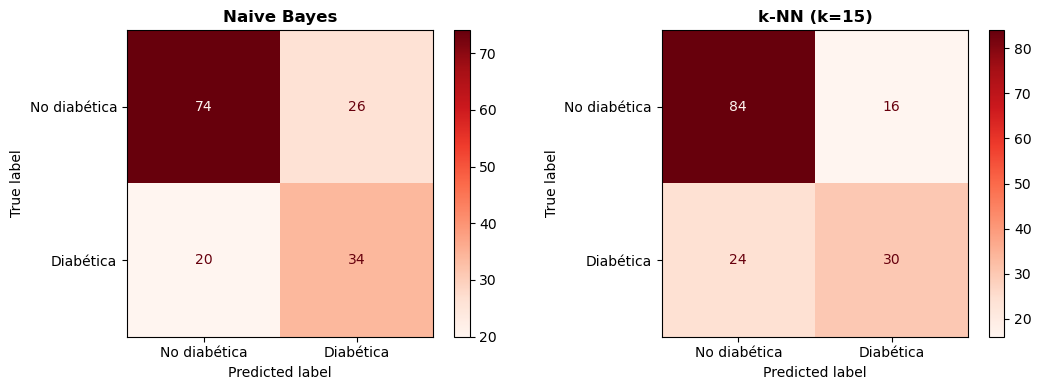

In [26]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica las dos matrices de confusión lado a lado (fig con 2 subplots)
# Usa ConfusionMatrixDisplay, cmap='Reds', labels=['No diabética', 'Diabética']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# Naive Bayes
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gnb,
    display_labels=['No diabética', 'Diabética'],
    cmap='Reds',
    ax=axes[0]
)
axes[0].set_title('Naive Bayes', fontweight='bold')

# k-NN
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=['No diabética', 'Diabética'],
    cmap='Reds',
    ax=axes[1]
)
axes[1].set_title(f'k-NN (k={k_optimo})', fontweight='bold')

plt.tight_layout()
plt.savefig('cm_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 7.2 — Tabla de métricas clínicas

In [28]:
# --- COMPLETA EL CÓDIGO ---
# TODO: calcula para ambos modelos: accuracy, precision, recall, f1
#       sobre la clase positiva (Diabética = 1)
#       imprime una tabla comparativa clara

metrics = {
    'Modelo': ['Naive Bayes', f'k-NN (k={k_optimo})'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_gnb),
        accuracy_score(y_test, y_pred_knn)
    ],
    'Precision (1)': [
        precision_score(y_test, y_pred_gnb, pos_label=1),
        precision_score(y_test, y_pred_knn, pos_label=1)
    ],
    'Recall (1)': [
        recall_score(y_test, y_pred_gnb, pos_label=1),
        recall_score(y_test, y_pred_knn, pos_label=1)
    ],
    'F1-score (1)': [
        f1_score(y_test, y_pred_gnb, pos_label=1),
        f1_score(y_test, y_pred_knn, pos_label=1)
    ]
}

df_metrics = pd.DataFrame(metrics)
print(df_metrics.round(4))

print('\n→ ¿Cuál modelo tiene mayor Recall? ¿Por qué eso importa clínicamente?')
print('El modelo con mayor Recall es el de Naive Bayes y la importancia de este valor es que \n'
      'maximiza la detección de pacientes diabéticos.')


        Modelo  Accuracy  Precision (1)  Recall (1)  F1-score (1)
0  Naive Bayes    0.7013         0.5667      0.6296        0.5965
1  k-NN (k=15)    0.7403         0.6522      0.5556        0.6000

→ ¿Cuál modelo tiene mayor Recall? ¿Por qué eso importa clínicamente?
El modelo con mayor Recall es el de Naive Bayes y la importancia de este valor es que 
maximiza la detección de pacientes diabéticos.


### Paso 7.3 — Gráfico comparativo de métricas

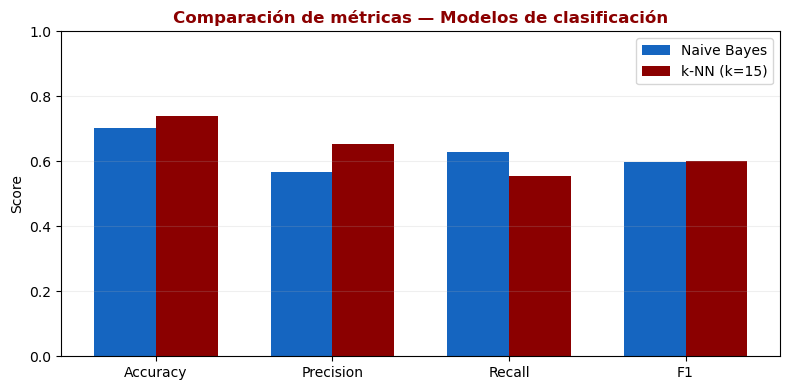

In [29]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica un bar chart comparando accuracy, precision, recall y F1
# para k-NN y Naive Bayes, con colores UPCH

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']

gnb_vals = [
    accuracy_score(y_test, y_pred_gnb),
    precision_score(y_test, y_pred_gnb, pos_label=1),
    recall_score(y_test, y_pred_gnb, pos_label=1),
    f1_score(y_test, y_pred_gnb, pos_label=1)
]

knn_vals = [
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn, pos_label=1),
    recall_score(y_test, y_pred_knn, pos_label=1),
    f1_score(y_test, y_pred_knn, pos_label=1)
]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - width/2, gnb_vals, width, label='Naive Bayes', color=UPCH_BLUE)
ax.bar(x + width/2, knn_vals, width, label=f'k-NN (k={k_optimo})', color=UPCH_RED)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Comparación de métricas — Modelos de clasificación', fontweight='bold', color=UPCH_RED)
ax.legend()
ax.grid(True, axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Ejercicio 8 — Umbral de decisión y probabilidades posteriores

Naive Bayes entrega **probabilidades**, no solo etiquetas. En clínica podemos ajustar el umbral de decisión según el contexto:
- Tamizaje masivo → umbral bajo → maximizar recall (menos FN)
- Confirmación diagnóstica → umbral alto → maximizar precision (menos FP)

Por defecto, scikit-learn usa umbral = 0.5.

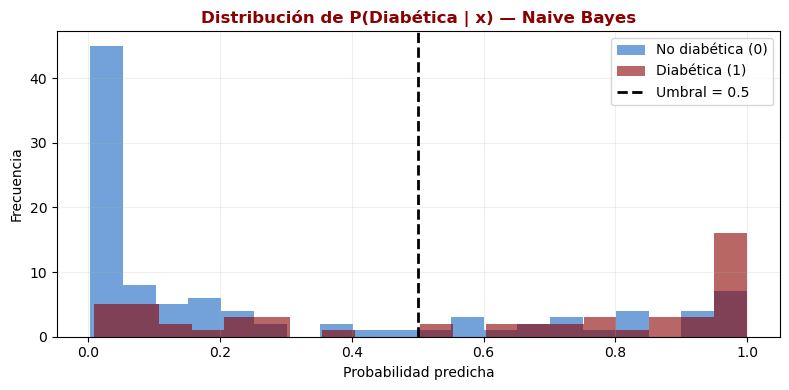

In [30]:
# Probabilidades posteriores de Naive Bayes
proba_gnb = gnb.predict_proba(X_test_imp)[:, 1]  # P(Diabética | x)

# --- COMPLETA EL CÓDIGO ---
# TODO 1: grafica el histograma de probabilidades P(Diabética | x)
#         diferenciando por clase real (y_test == 0 y y_test == 1)
#         con alpha=0.6, UPCH_BLUE y UPCH_RED
#         agrega una línea vertical en 0.5 (umbral por defecto)

fig, ax = plt.subplots(figsize=(8, 4))
# Clase 0 (No diabética)
ax.hist(
    proba_gnb[y_test == 0],
    bins=20,
    alpha=0.6,
    color=UPCH_BLUE,
    label='No diabética (0)'
)

# Clase 1 (Diabética)
ax.hist(
    proba_gnb[y_test == 1],
    bins=20,
    alpha=0.6,
    color=UPCH_RED,
    label='Diabética (1)'
)

# Línea de umbral
ax.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Umbral = 0.5')

ax.set_title('Distribución de P(Diabética | x) — Naive Bayes', fontweight='bold', color=UPCH_RED)
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('histograma_proba.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# --- COMPLETA EL CÓDIGO ---
# TODO 2: evalúa el modelo con umbral = 0.35 (tamizaje) y umbral = 0.65 (confirmación)
#         Compara recall y precision en ambos casos vs el umbral por defecto (0.5)
#         Imprime una tabla con: umbral, precision, recall, F1

for umbral in [0.35, 0.50, 0.65]:
    y_pred_umbral=(proba_gnb >= umbral).astype(int)
    
    precision = precision_score(y_test, y_pred_umbral, pos_label=1)
    recall    = recall_score(y_test, y_pred_umbral, pos_label=1)
    f1        = f1_score(y_test, y_pred_umbral, pos_label=1)
    
    print(f'{umbral:>8.2f} | {precision:>10.4f} | {recall:>8.4f} | {f1:>6.4f}')

print()
print('→ ¿Para un programa de tamizaje de diabetes en comunidades rurales del Perú,')
print('  qué umbral recomendarías y por qué?')

print('Para un programa de tamizaje recomendaría el umbral de 0.35, ya que maximiza el recall, permitiendo \n'
      'detectar la mayor cantidad de pacientes diabéticos.')

    0.35 |     0.5385 |   0.6481 | 0.5882
    0.50 |     0.5667 |   0.6296 | 0.5965
    0.65 |     0.5882 |   0.5556 | 0.5714

→ ¿Para un programa de tamizaje de diabetes en comunidades rurales del Perú,
  qué umbral recomendarías y por qué?
Para un programa de tamizaje recomendaría el umbral de 0.35, ya que maximiza el recall, permitiendo 
detectar la mayor cantidad de pacientes diabéticos.


---
## Ejercicio 9 — Impacto del Prior (reflexión bayesiana)

El Teorema de Bayes que estudiamos en Clase 1 está en el corazón de Naive Bayes. Ahora lo aplicamos directamente.

In [34]:
# Naive Bayes con prior ajustado manualmente
# Simulamos que estamos en una población con baja prevalencia de diabetes (5%)

# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena un GaussianNB con priors=[0.95, 0.05]
#         (usar parámetro priors= en el constructor)
gnb_low_prev=GaussianNB(priors=[0.95, 0.05])
gnb_low_prev.fit(X_train_imp, y_train)

# TODO 2: predice y calcula recall, precision y accuracy en test
y_pred_lp=gnb_low_prev.predict(X_test_imp)

print('Comparación de priors:')
print(f'  Prior original (~35% diabetes):  Recall={recall_score(y_test, y_pred_gnb):.4f}  Precision={precision_score(y_test, y_pred_gnb):.4f}')
print(f'  Prior 5% diabetes:               Recall={recall_score(y_test, y_pred_lp):.4f}  Precision={precision_score(y_test, y_pred_lp):.4f}')
print()
print('📝 Reflexión: ¿Qué le ocurre al recall cuando la prevalencia baja?')
print('   Conecta esto con la Actividad 4 de Clase 1 (Teorema de Bayes).')

print('Al disminuir la prevalencia, el recall disminuye porque el modelo requiere mayor evidencia para clasificar \n'
      'un paciente diabético. Esto se explica por el Teorema de Bayes, donde una menor probabilidad reduce la \n'
      'probabilidad posterior de la clase positiva.')

Comparación de priors:
  Prior original (~35% diabetes):  Recall=0.6296  Precision=0.5667
  Prior 5% diabetes:               Recall=0.3519  Precision=0.6333

📝 Reflexión: ¿Qué le ocurre al recall cuando la prevalencia baja?
   Conecta esto con la Actividad 4 de Clase 1 (Teorema de Bayes).
Al disminuir la prevalencia, el recall disminuye porque el modelo requiere mayor evidencia para clasificar 
un paciente diabético. Esto se explica por el Teorema de Bayes, donde una menor probabilidad reduce la 
probabilidad posterior de la clase positiva.


---
## Ejercicio 10 — Análisis final e interpretación clínica

Responde las siguientes preguntas integrando los resultados obtenidos:

### 10.1 — ¿Cuál modelo elegirías y para qué escenario?

Completa la tabla:

| Escenario | Modelo recomendado | Métrica prioritaria | Justificación |
|---|---|---|---|
| Screening masivo en posta rural | Naive Bayes | Recall | Es el modelo que presenta un mayor recall, por lo que detecta una mayor proporción de pacientes positivas. Como mencionado en el ejercicio 1, clínicamente es preferible minimizar los falsos negativos |
| Confirmación diagnóstica en hospital | k-NN | Precision | Es el modelo con mayor precision y mayor accuracy. En un entorno hospitalario, en el momento de diagnóstico, sí es preferible la confiabilidad en predicciones positivas, así se reduce los falsos positivos y se puede tomar una mejor decisión clínica. |
| Sistema embebido en glucómetro portátil | Naive Bayes | Recall - Eficiencia computacional | Aunque sea inferior en las estadísticas globales, aún posee un mayor recall y es el modelo con menor costo computacional, entonces es un modelo más conveniente para un sistema portátil.  |

**📝 Tu respuesta (edita esta celda)**

### 10.2 — Limitaciones del análisis

1. ¿Qué asunciones de Naive Bayes se violan en este dataset? ¿Cómo lo detectaste?
2. ¿Por qué k-NN puede ser problemático si el dataset tuviera 50,000 pacientes y 200 features?
3. ¿Qué otra métrica de evaluación sería importante reportar en el contexto clínico?

**📝 Tu respuesta (edita esta celda):**
1. En el dataset se viola la asunción de independencia condicional de Naive Bayes, ya que como mencionado en el primer ejercicio, se posee variables clínicas relacionadas entre sí. Esto puede inferirse tanto por conocimiento clínico, ya que se puede saber la relación fisiológica entre variables, como por la matriz de correlación, donde efectivamente se puede observar que las variables no son totalmente independientes entre sí, dados valores como 0.65, 0.58 o 0.54.
2. Al poseer una mayor cantidad de data, su costo computacional inicial aumentaría más. El costo de predicción será mayor, ya que para cada paciente deberá calcular la distancia de sus variables contra los 50,000 existentes, además de que se empeora por el espacio tan grande que representan 200 dimensiones. Además, como debe mantener en todo momento los valores cargados, se necesitaría una buena capacidad para la memoria RAM.
3. En un contexto clínico la Especificidad es importante, porque permite evaluar que tan bien el modelo identifica de forma correcta a los pacientes sanos, controlando de mejor manera los falsos positivos, complementando métricas como Recall.

In [35]:
# Resumen ejecutivo final
print('=' * 60)
print('          RESUMEN DEL CHALLENGE 2')
print('=' * 60)
print(f'Dataset: Pima Indians Diabetes  (N={len(df)}, d=8)')
print(f'Prevalencia en test: {100*(y_test==1).mean():.1f}%')
print()
print(f'{"Modelo":<20} {"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1"}')
print('-' * 60)

for nombre, y_p in [(f'k-NN (k={k_optimo})', y_pred_knn), ('Naive Bayes', y_pred_gnb)]:
    print(f'{nombre:<20} '
          f'{accuracy_score(y_test, y_p):.4f}       '
          f'{recall_score(y_test, y_p):.4f}       '
          f'{precision_score(y_test, y_p):.4f}       '
          f'{f1_score(y_test, y_p):.4f}')

print()
print('Archivos generados:')
print('  distribucion_diabetes.png   eda_diabetes.png')
print('  knn_seleccion_k_diabetes.png cm_comparacion.png')
print('  comparacion_metricas.png    histograma_proba.png')

          RESUMEN DEL CHALLENGE 2
Dataset: Pima Indians Diabetes  (N=768, d=8)
Prevalencia en test: 35.1%

Modelo               Accuracy     Recall       Precision    F1
------------------------------------------------------------
k-NN (k=15)          0.7403       0.5556       0.6522       0.6000
Naive Bayes          0.7013       0.6296       0.5667       0.5965

Archivos generados:
  distribucion_diabetes.png   eda_diabetes.png
  knn_seleccion_k_diabetes.png cm_comparacion.png
  comparacion_metricas.png    histograma_proba.png
